# Single Pixel Imaging

Plan:

1. load actual scene image
2. generate random matrices for Digital Mirror Device (DMD)
3. multiply image with random matrices to take Single Pixel Imaging samples 
4. attempt to recreate image from SPI samples
5. use compressive sampling to reconstruct image from limited data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import PIL

from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge
from PIL import Image
from tqdm import tqdm

In [90]:
# Image size
SIZE = 64

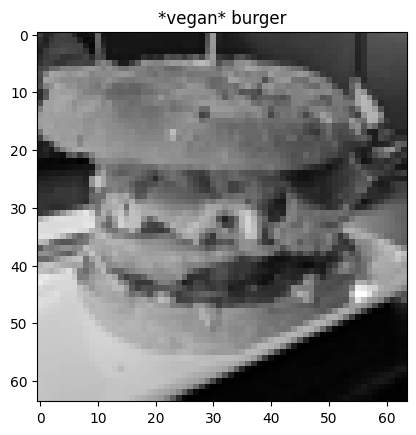

In [58]:
# read image and convert to grey scale
x_image = Image.open("vegan-burger.jpg").convert("L").crop(box=(0+300,0,1080+300,1080)).resize((SIZE, SIZE), Image.BICUBIC)
x_image = np.asarray(x_image)

plt.imshow(x_image, cmap="grey")
plt.title("*vegan* burger");

In [91]:
# normalize image to [0,1]
x = x_image.flatten() / 255

In [5]:
x.shape

(4096,)

## 2. Generate DMD Sampling Matrices

We will generate random matrices that control, if the individual mirrors of the DMD reflect the scene light towards the sensor or not.

In [6]:
phi = np.random.randint(2, size=(len(x), len(x)))

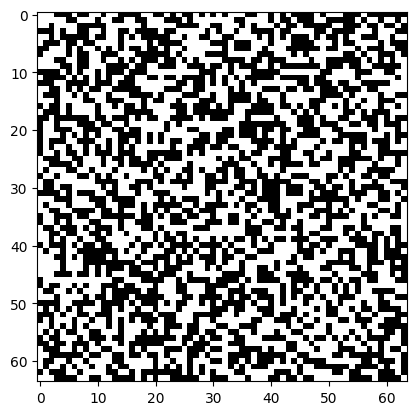

In [7]:
plt.imshow(phi[0].reshape(SIZE, SIZE), cmap="binary");

## 3. Simulate single pixel sensor observations

In [92]:
# this is the signal that our single pixel sensor measures!
# optionally, add noise
y = phi @ x
noise = np.random.normal(0, 0.001 * y.std(), size=len(y))
y_noisy = y + noise

In [93]:
# 
y_noisy[0]

np.float64(852.020959285015)

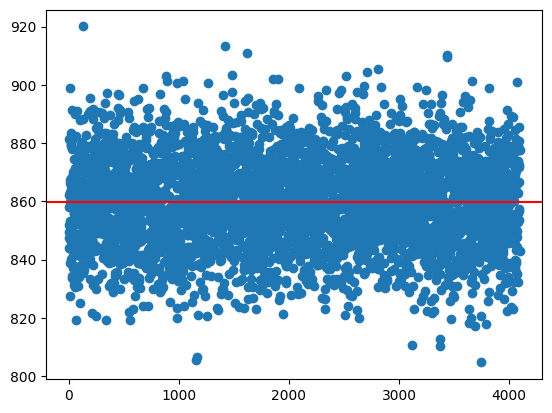

In [94]:
plt.scatter(np.arange(len(y_noisy)), y_noisy)
plt.axhline(y_noisy.mean(), c="red")

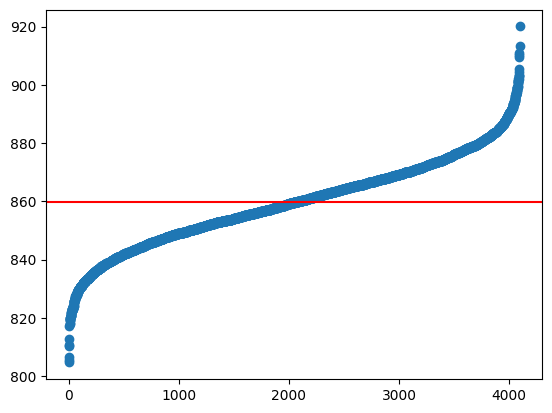

In [95]:
plt.scatter(np.arange(len(y_noisy)), np.sort(y_noisy))
plt.axhline(y_noisy.mean(), c="r")

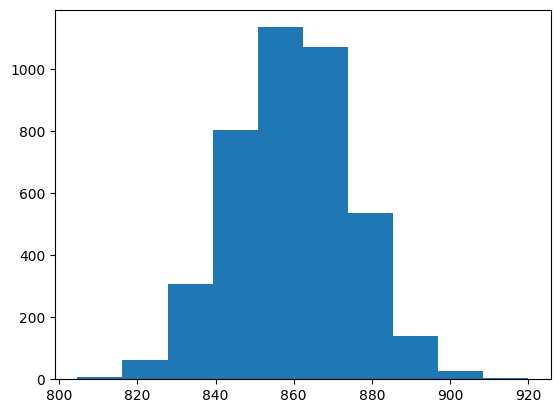

In [96]:
plt.hist(y_noisy);

## 4. Reconstruct image from measurements

In [97]:
phi.shape

(4096, 4096)

Can we reconstruct the original input image - from this???

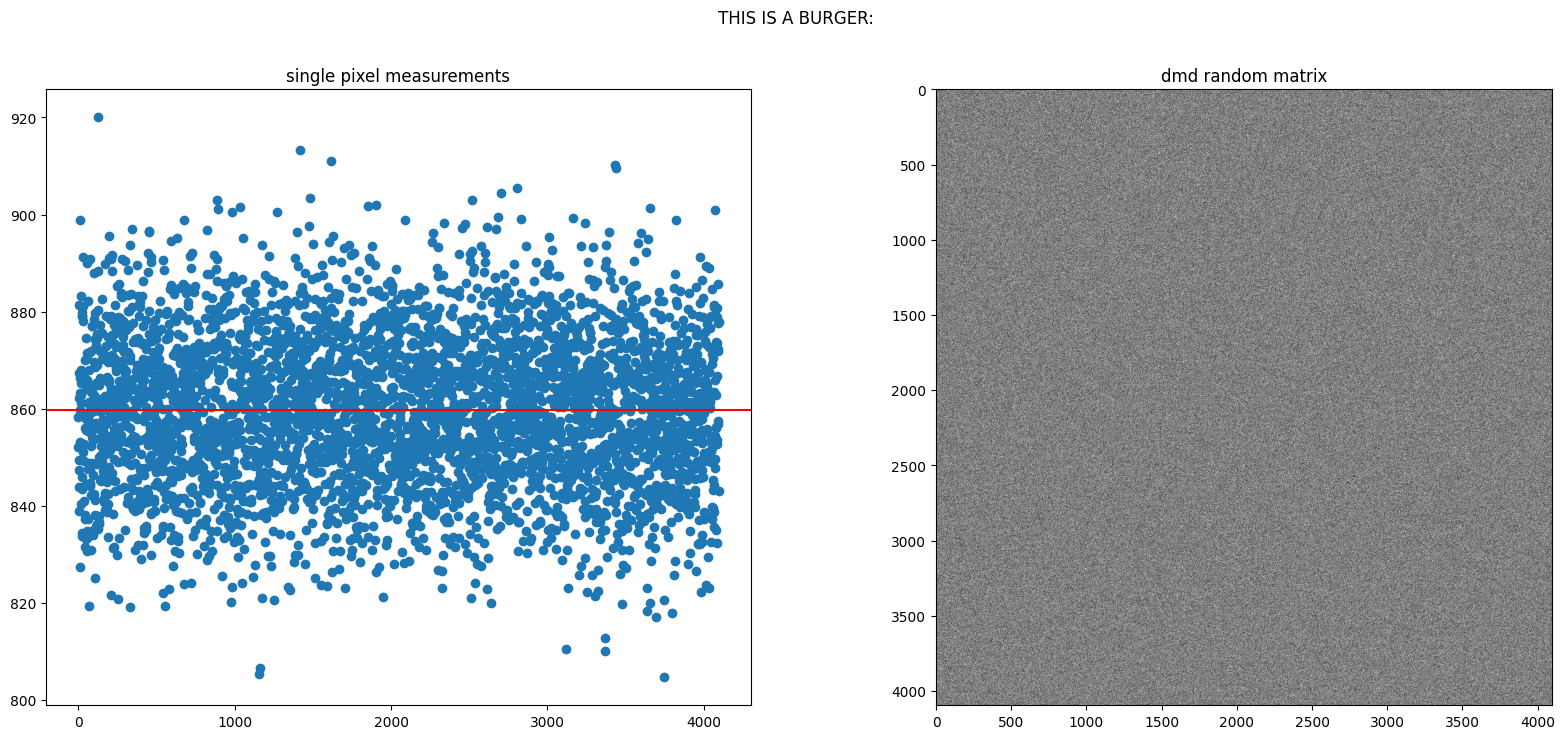

In [104]:
fig, axs = plt.subplots(1,2, figsize=(20, 8))

axs[0].scatter(np.arange(len(y_noisy)), y_noisy)
axs[0].set_title("single pixel measurements")
axs[0].axhline(y_noisy.mean(), c="red")

axs[1].imshow(phi, cmap="binary", vmin=0, vmax=1)
axs[1].set_title("dmd random matrix")

fig.suptitle("THIS IS A BURGER:")

plt.show();

Single-Pixel Imaging:

$$
    y = \Phi x
$$

Linear Regression:

$$
    y = X \beta
$$

## 

In [ ]:
# model = LinearRegression()
# already regularized linear regression

model = Ridge()
model.fit(phi, y_noisy)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


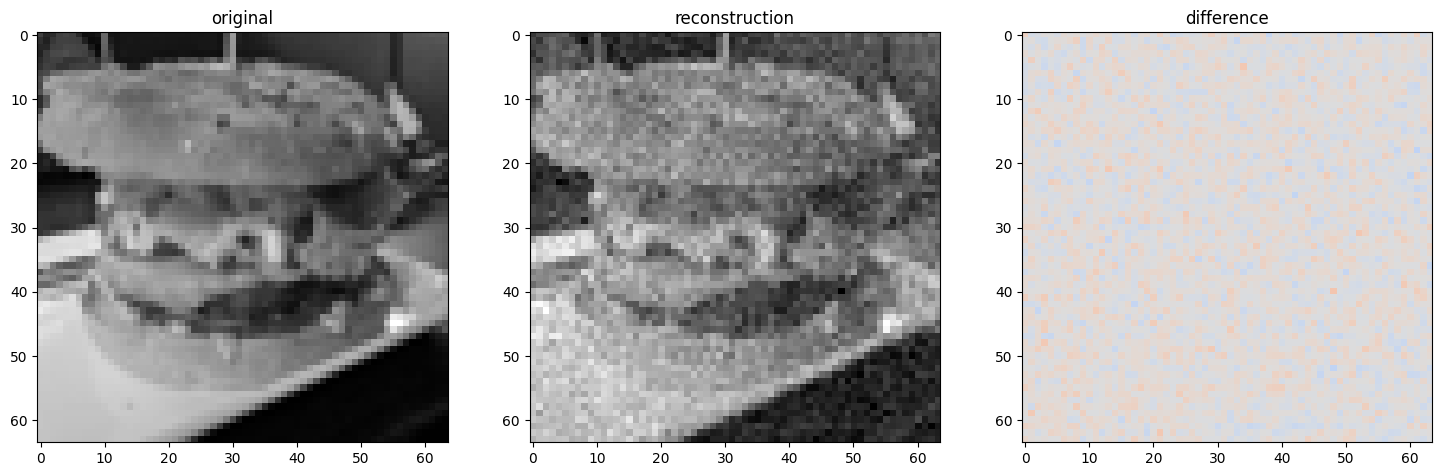

In [16]:
fig, axs = plt.subplots(1,3, figsize=(18, 6))

axs[0].imshow(x.reshape(SIZE, SIZE), cmap="grey")
axs[0].set_title("original")

axs[1].imshow(model.coef_.reshape(SIZE,SIZE), cmap="grey")
axs[1].set_title("reconstruction");

im = axs[2].imshow((x - model.coef_).reshape(SIZE, SIZE), cmap="coolwarm", vmin=-1, vmax=1)
axs[2].set_title("difference");

#plt.colorbar(im)

# 5. Compressive Sampling

Previously, we had one observation per pixel - however, we would like to keep the number of required measurements we need to take as low as possible.

We will use *compressive sampling* for that:
Assuming, that our image can be compressed, we can exploit the sparsity of the compressed image.
JPG compression uses a block-wise *Discrete Fourier Transform* (DCT) to represent each 8 by 8 pixel block as the sum of different frequencies.
If we throw away high frequencies, like random noise, we end up with a sparse representation of the image, where many of the DCT coefficients are 0.

If we now use linear regression with LASSO regularization, we can reconstruct the image even if we have only 50% of the measurements available!

In [18]:
def get_dct_matrix(n):
    DCT = np.zeros((n, n))
    for i in range(n):
        alpha = np.sqrt(1/n) if i == 0 else np.sqrt(2/n)
        for j in range(n):
            DCT[i, j] = alpha * np.cos(np.pi * (j + 0.5) * i / n)
    return DCT


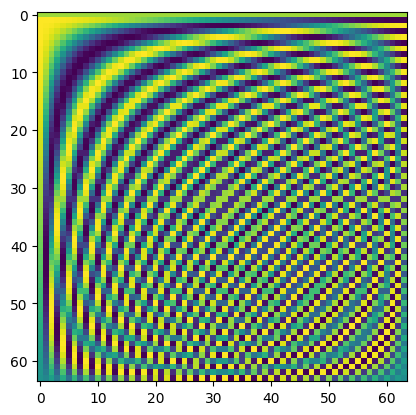

In [105]:
DCT = get_dct_matrix(64)

plt.imshow(DCT);

In [113]:
# we need to perform DCT over both rows and columns
psi = np.kron(DCT, DCT)

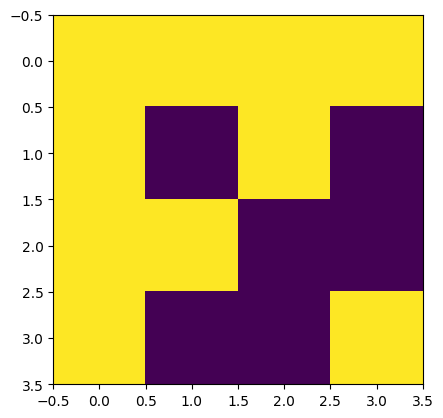

In [111]:
def plot_kron():
    "visualization of the kronecker product"

    a = np.array([
        [1, 1],
        [1, -1]
    ])

    c = np.kron(a,a)
    plt.imshow(c)

plot_kron()

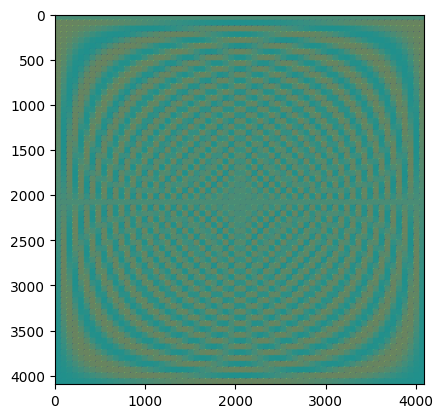

In [112]:
plt.imshow(psi);

Idea: Using Discrete Cosine Transform (DCT), we can express our original image vector $x$ as Product of the transformation matrix $\Psi$ and coefficients $\alpha$:

$$
    x = \Psi \alpha
$$

If we plug this into our regression problem, we get:

$$
    y = \Phi x = \Phi (\Psi \alpha) = (\Phi \Psi) \alpha
$$

In [ ]:
def reconstruct(x, phi, psi, ratio: float = 1.0):
    # using the right regularization strength (alpha) is key
    model = Lasso(alpha=1e-3)

    N_OBS = int(len(x) * ratio)

    model.fit(phi[:N_OBS] @ psi, y_noisy[:N_OBS])

    z = (psi @ model.coef_).reshape(SIZE, SIZE)
    return z

In [107]:
z = reconstruct(x, phi, psi)

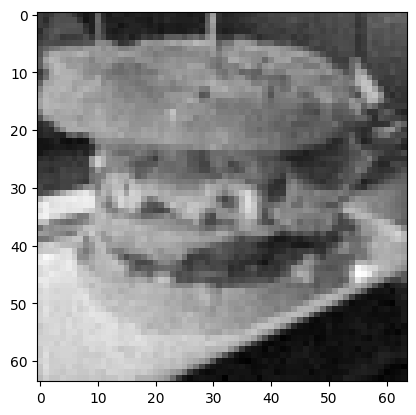

In [108]:
plt.imshow(z, cmap="gray");

In [55]:
reconstructions = {}
ratios = np.linspace(0.1, 1.0, 10)

for ratio in tqdm(ratios):
    z = reconstruct(x, phi, psi, ratio)
    reconstructions[ratio] = z

100%|██████████| 10/10 [00:38<00:00,  3.86s/it]


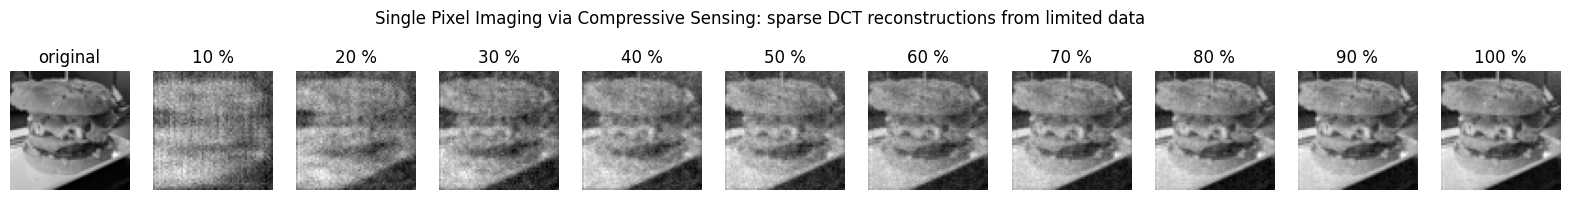

In [88]:
def plot_reconstructions():
    fig, axs = plt.subplots(ncols=11, figsize=(20,2.5))

    axs[0].imshow(x_image, cmap="gray")
    axs[0].axis(False)
    axs[0].set_title("original")

    for i, ratio in enumerate(ratios):
        axs[i+1].imshow(reconstructions[ratio], cmap="gray")
        axs[i+1].set_title(f"{ratio * 100:.0f} %")
        axs[i+1].axis(False)

    plt.suptitle("Single Pixel Imaging via Compressive Sensing: sparse DCT reconstructions from limited data")
    plt.show()

plot_reconstructions()

# Bookmarks

- [Duarte et al.: Single-pixel imaging via compressive sampling (2008)](https://doi.org/10.1109/MSP.2007.914730)
- https://opg.optica.org/oe/fulltext.cfm?uri=oe-28-19-28190